AutoML_Flaml para desempeño de modelos

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split

In [2]:
DATA_DIR = Path.cwd().resolve().parent / "datos"

df_bank = pd.read_parquet(DATA_DIR / "02_datos_con_tipo_de_dato_ajustado_banko.parquet")

In [3]:
#y = df_bank["y"].map({'no': 0, 'yes': 1}) otra opcion
X = df_bank.drop(columns=["y"])
y = df_bank["y"].astype(str)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2
)

In [4]:
df_bank.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45211 entries, 0 to 45210
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype   
---  ------     --------------  -----   
 0   age        45211 non-null  int64   
 1   job        45211 non-null  category
 2   marital    45211 non-null  category
 3   education  45211 non-null  category
 4   default    45211 non-null  category
 5   balance    45211 non-null  float64 
 6   housing    45211 non-null  category
 7   loan       45211 non-null  category
 8   contact    45211 non-null  category
 9   day        45211 non-null  int64   
 10  month      45211 non-null  category
 11  duration   45211 non-null  int64   
 12  campaign   45211 non-null  int64   
 13  pdays      45211 non-null  int64   
 14  previous   45211 non-null  int64   
 15  poutcome   45211 non-null  category
 16  y          45211 non-null  object  
dtypes: category(9), float64(1), int64(6), object(1)
memory usage: 3.1+ MB


In [5]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline

In [6]:
numeric_features = ["age", "balance", "day", "duration","campaign", "pdays","previous"]
categorical_features = ["job", "marital","default","housing","loan","contact","month","poutcome"]
ordinal_features = ["education"]


numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median"))
])

ordinal_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("ordinal", OrdinalEncoder(categories=[['tertiary', 'secondary', 'primary', 'unknown']]))
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("ord", ordinal_transformer, ordinal_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)

In [7]:
from flaml import AutoML
from sklearn.pipeline import Pipeline as SKLearnPipeline

automl = AutoML()

In [8]:
X_train_preprocessed = preprocessor.fit_transform(X_train)

X_test_preprocessed = preprocessor.fit_transform(X_test)

automl_settings = {
    "time_budget": 60,  # total running time in seconds
    "metric": 'accuracy',  # primary metric to optimize
    "task": 'classification',  # task type
    "estimator_list": ['lgbm', 'xgboost', 'lrl1', 'rf'],  # list of ML learners
    "log_file_name": 'flaml_banco_automl.log',  # flaml log file
    "seed": 42
}

automl.fit(X_train_preprocessed, y_train, **automl_settings)

[flaml.automl.logger: 11-03 17:19:25] {1752} INFO - task = classification
[flaml.automl.logger: 11-03 17:19:25] {1763} INFO - Evaluation method: holdout
[flaml.automl.logger: 11-03 17:19:26] {1862} INFO - Minimizing error metric: 1-accuracy
[flaml.automl.logger: 11-03 17:19:26] {1979} INFO - List of ML learners in AutoML Run: ['lgbm', 'xgboost', 'lrl1', 'rf']
[flaml.automl.logger: 11-03 17:19:26] {2282} INFO - iteration 0, current learner lgbm
[flaml.automl.logger: 11-03 17:19:26] {2417} INFO - Estimated sufficient time budget=1473s. Estimated necessary time budget=24s.
[flaml.automl.logger: 11-03 17:19:26] {2466} INFO -  at 0.3s,	estimator lgbm's best error=0.1174,	best estimator lgbm's best error=0.1174
[flaml.automl.logger: 11-03 17:19:26] {2282} INFO - iteration 1, current learner lgbm


c:\Users\aical\Documents\JM_SD_SC_marketing_bancario\.venv\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
c:\Users\aical\Documents\JM_SD_SC_marketing_bancario\.venv\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[flaml.automl.logger: 11-03 17:19:26] {2466} INFO -  at 0.5s,	estimator lgbm's best error=0.1174,	best estimator lgbm's best error=0.1174
[flaml.automl.logger: 11-03 17:19:26] {2282} INFO - iteration 2, current learner lgbm
[flaml.automl.logger: 11-03 17:19:26] {2466} INFO -  at 0.8s,	estimator lgbm's best error=0.1174,	best estimator lgbm's best error=0.1174
[flaml.automl.logger: 11-03 17:19:26] {2282} INFO - iteration 3, current learner xgboost


c:\Users\aical\Documents\JM_SD_SC_marketing_bancario\.venv\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[flaml.automl.logger: 11-03 17:19:27] {2466} INFO -  at 1.0s,	estimator xgboost's best error=0.1174,	best estimator lgbm's best error=0.1174
[flaml.automl.logger: 11-03 17:19:27] {2282} INFO - iteration 4, current learner lgbm
[flaml.automl.logger: 11-03 17:19:27] {2466} INFO -  at 1.2s,	estimator lgbm's best error=0.1042,	best estimator lgbm's best error=0.1042
[flaml.automl.logger: 11-03 17:19:27] {2282} INFO - iteration 5, current learner xgboost
[flaml.automl.logger: 11-03 17:19:27] {2466} INFO -  at 1.3s,	estimator xgboost's best error=0.1174,	best estimator lgbm's best error=0.1042
[flaml.automl.logger: 11-03 17:19:27] {2282} INFO - iteration 6, current learner lgbm


...

[flaml.automl.logger: 11-03 17:20:24] {2466} INFO -  at 58.2s,	estimator rf's best error=0.1006,	best estimator lgbm's best error=0.0873
[flaml.automl.logger: 11-03 17:20:24] {2282} INFO - iteration 100, current learner lgbm
[flaml.automl.logger: 11-03 17:20:24] {2466} INFO -  at 58.5s,	estimator lgbm's best error=0.0873,	best estimator lgbm's best error=0.0873
[flaml.automl.logger: 11-03 17:20:24] {2282} INFO - iteration 101, current learner lgbm


c:\Users\aical\Documents\JM_SD_SC_marketing_bancario\.venv\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[flaml.automl.logger: 11-03 17:20:24] {2466} INFO -  at 58.7s,	estimator lgbm's best error=0.0873,	best estimator lgbm's best error=0.0873
[flaml.automl.logger: 11-03 17:20:24] {2282} INFO - iteration 102, current learner xgboost


c:\Users\aical\Documents\JM_SD_SC_marketing_bancario\.venv\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[flaml.automl.logger: 11-03 17:20:25] {2466} INFO -  at 60.0s,	estimator xgboost's best error=0.0909,	best estimator lgbm's best error=0.0873
[flaml.automl.logger: 11-03 17:20:25] {2282} INFO - iteration 103, current learner lrl1
[flaml.automl.logger: 11-03 17:20:29] {2466} INFO -  at 63.8s,	estimator lrl1's best error=0.1174,	best estimator lgbm's best error=0.0873
[flaml.automl.logger: 11-03 17:20:30] {2724} INFO - retrain lgbm for 0.3s
[flaml.automl.logger: 11-03 17:20:30] {2727} INFO - retrained model: LGBMClassifier(colsample_bytree=np.float64(0.9789217450151927),
               learning_rate=np.float64(0.6517435002805259), max_bin=63,
               min_child_samples=7, n_estimators=150, n_jobs=-1, num_leaves=5,
               reg_alpha=np.float64(0.010571138066726337),
               reg_lambda=np.float64(2.9280760553561898), verbose=-1)
[flaml.automl.logger: 11-03 17:20:30] {2009} INFO - fit succeeded
[flaml.automl.logger: 11-03 17:20:30] {2010} INFO - Time taken to find the be

In [9]:
print("Mejor modelo encontrado", automl.best_estimator)

print("\n")

print("Mejor configuración de hiperparámetros:", automl.best_config)

print("\n")

print("Tiempo de búsqueda:", automl.time_to_find_best_model, "segundos")

Mejor modelo encontrado lgbm


Mejor configuración de hiperparámetros: {'n_estimators': 150, 'num_leaves': 5, 'min_child_samples': 7, 'learning_rate': np.float64(0.6517435002805259), 'log_max_bin': 6, 'colsample_bytree': np.float64(0.9789217450151927), 'reg_alpha': np.float64(0.010571138066726337), 'reg_lambda': np.float64(2.9280760553561898)}


Tiempo de búsqueda: 50.64257478713989 segundos


In [10]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

y_pred = automl.predict(X_test_preprocessed)

y_pred_proba = automl.predict_proba(X_test_preprocessed)[:, 1]

c:\Users\aical\Documents\JM_SD_SC_marketing_bancario\.venv\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
c:\Users\aical\Documents\JM_SD_SC_marketing_bancario\.venv\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


In [11]:
test_accuracy = accuracy_score(y_test, y_pred)

print("\n")

print(classification_report(y_test, y_pred, target_names=["No adquirió", "Adquirió"]))



              precision    recall  f1-score   support

 No adquirió       0.94      0.96      0.95      7994
    Adquirió       0.63      0.50      0.56      1049

    accuracy                           0.91      9043
   macro avg       0.78      0.73      0.75      9043
weighted avg       0.90      0.91      0.90      9043



<Axes: >

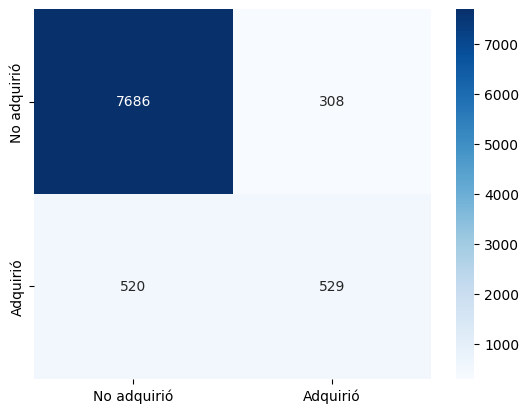

In [12]:
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=["No adquirió", "Adquirió"], yticklabels=["No adquirió", "Adquirió"])

In [13]:
df_predictions = X_test.copy()

In [14]:
X_test

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome
40643,27,management,single,tertiary,no,6791.0,no,no,cellular,5,aug,179,2,69,26,other
37800,58,self-employed,married,secondary,no,28318.0,yes,no,cellular,14,may,168,2,-1,0,unknown
19654,35,management,married,tertiary,no,416.0,no,no,cellular,7,aug,163,4,-1,0,unknown
4676,59,entrepreneur,married,tertiary,no,705.0,yes,no,unknown,20,may,446,2,-1,0,unknown
35449,38,services,married,primary,no,0.0,yes,yes,cellular,7,may,127,1,171,2,other
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
37094,37,services,single,secondary,no,-111.0,yes,no,cellular,13,may,147,4,-1,0,unknown
24550,50,admin.,married,unknown,no,4861.0,no,no,cellular,17,nov,256,2,-1,0,unknown
23439,33,management,married,tertiary,no,1138.0,no,no,cellular,28,aug,73,4,-1,0,unknown
27081,33,blue-collar,single,secondary,no,5739.0,yes,yes,cellular,21,nov,374,1,-1,0,unknown


In [15]:
df_predictions["adquiere_real"] = y_test.values

df_predictions["prediction_label"] = y_pred

df_predictions["prediction_score"] = y_pred_proba

print(df_predictions[['age', 'education','housing','adquiere_real', 'prediction_label', 'prediction_score']].sample(10))

       age  education housing adquiere_real prediction_label  prediction_score
7506    44  secondary     yes            no               no          0.000047
32274   25    unknown     yes            no               no          0.074051
19753   32   tertiary      no            no               no          0.087931
31627   38   tertiary     yes            no               no          0.009004
2696    41  secondary     yes            no               no          0.000039
30808   52  secondary     yes            no               no          0.000665
21553   45  secondary      no            no               no          0.000577
34905   33  secondary     yes            no               no          0.019786
12761   30  secondary     yes            no               no          0.000276
39324   32  secondary     yes            no               no          0.033872


Guardamos el modelo 1

In [16]:
full_pipeline = SKLearnPipeline(steps=[
    ("preprocessor", preprocessor),
    ("automl", automl.model)
])

print(full_pipeline)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median'))]),
                                                  ['age', 'balance', 'day',
                                                   'duration', 'campaign',
                                                   'pdays', 'previous']),
                                                 ('ord',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('ordinal',
                                                                   OrdinalEncoder(categories=[['tertiary',
                                                                          

In [17]:
import joblib 

model_filename = DATA_DIR / "lightgbm_flaml_automl_model.joblib"
joblib.dump(full_pipeline, model_filename)

['C:\\Users\\aical\\Documents\\JM_SD_SC_marketing_bancario\\datos\\lightgbm_flaml_automl_model.joblib']